# Lab 8: Finding and Handling Missing Values
## IBM Data Analytics Capstone Project 
### Objective: Identify, quantify, impute and visualize missing values in the Stack Overflow Developer Survey dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

print(" Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [3]:
# Display basic information
print("Dataset Info:")
print(df.info())
print("\nSummary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB
None

Summary Statistics:


,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [4]:
# Identify missing values for all columns
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent.round(2)
}).sort_values('Missing Values', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Values'] > 0]
print(f"Total columns with missing values: {len(missing_df)}")
print("\nTop 20 columns with most missing values:")
print(missing_df.head(20))

Total columns with missing values: 109

Top 20 columns with most missing values:
                               Missing Values  Percentage (%)
AINextMuch less integrated              64289           98.25
AINextLess integrated                   63082           96.40
AINextNo change                         52939           80.90
AINextMuch more integrated              51999           79.46
EmbeddedAdmired                         48704           74.43
EmbeddedWantToWorkWith                  47837           73.10
EmbeddedHaveWorkedWith                  43223           66.05
ConvertedCompYearly                     42002           64.19
AIToolNot interested in Using           41023           62.69
AINextMore integrated                   41009           62.67
Knowledge_9                             37802           57.77
Frequency_3                             37727           57.65
Knowledge_8                             37679           57.58
ProfessionalTech                        37673      

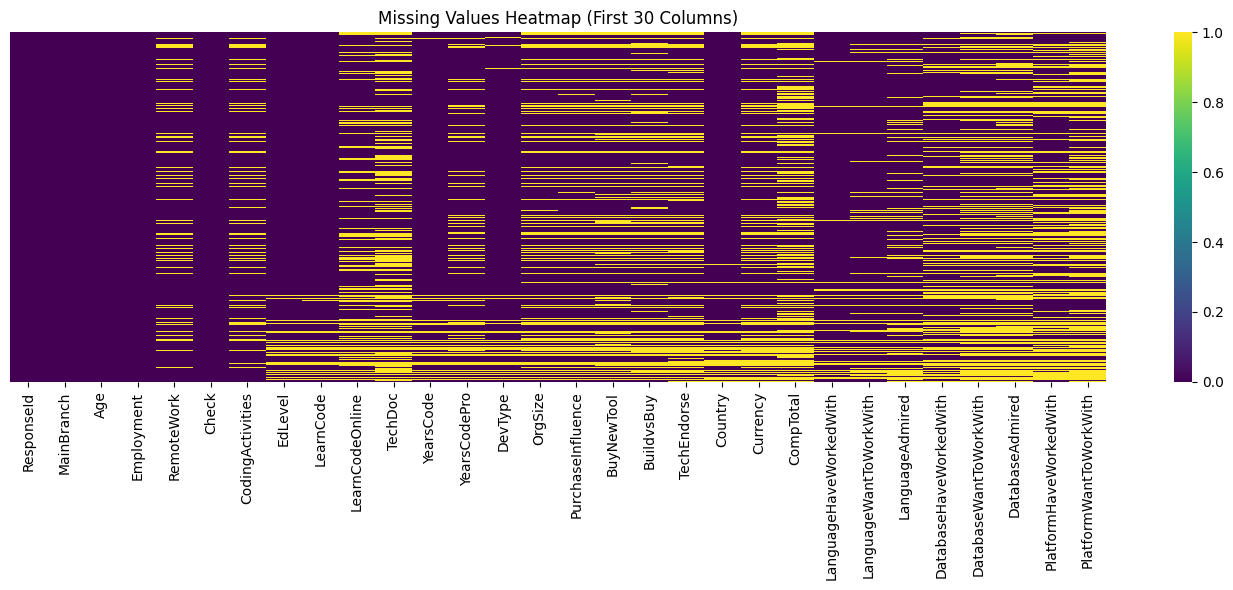

 Heatmap saved!


In [5]:
# Visualize missing values using heatmap (sample for performance)
plt.figure(figsize=(14, 6))
sample_df = df.iloc[:, :30]  # first 30 columns for clarity
sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False, 
            cmap='viridis')
plt.title('Missing Values Heatmap (First 30 Columns)')
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved!")

In [6]:
# Count missing rows for Employment column
employment_missing = df['Employment'].isnull().sum()
print("Missing values in Employment column:", employment_missing)
print("Percentage missing:", round((employment_missing / len(df)) * 100, 2), "%")

Missing values in Employment column: 0
Percentage missing: 0.0 %


In [7]:
# Identify the most frequent value in Employment
most_frequent_employment = df['Employment'].value_counts().idxmax()
print("Most frequent Employment value:")
print(most_frequent_employment)
print("\nEmployment value counts:")
print(df['Employment'].value_counts())

Most frequent Employment value:
Employed, full-time

Employment value counts:
Employment
Employed, full-time                                                                                                                                  39041
Independent contractor, freelancer, or self-employed                                                                                                  4846
Student, full-time                                                                                                                                    4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                              3557
Not employed, but looking for work                                                                                                                    2341
                                                                                                                                        

In [8]:
# Impute missing values with most frequent value
df['Employment'] = df['Employment'].fillna(most_frequent_employment)
print("Missing values after imputation:", df['Employment'].isnull().sum())
print(" Employment column imputed successfully!")

Missing values after imputation: 0
 Employment column imputed successfully!


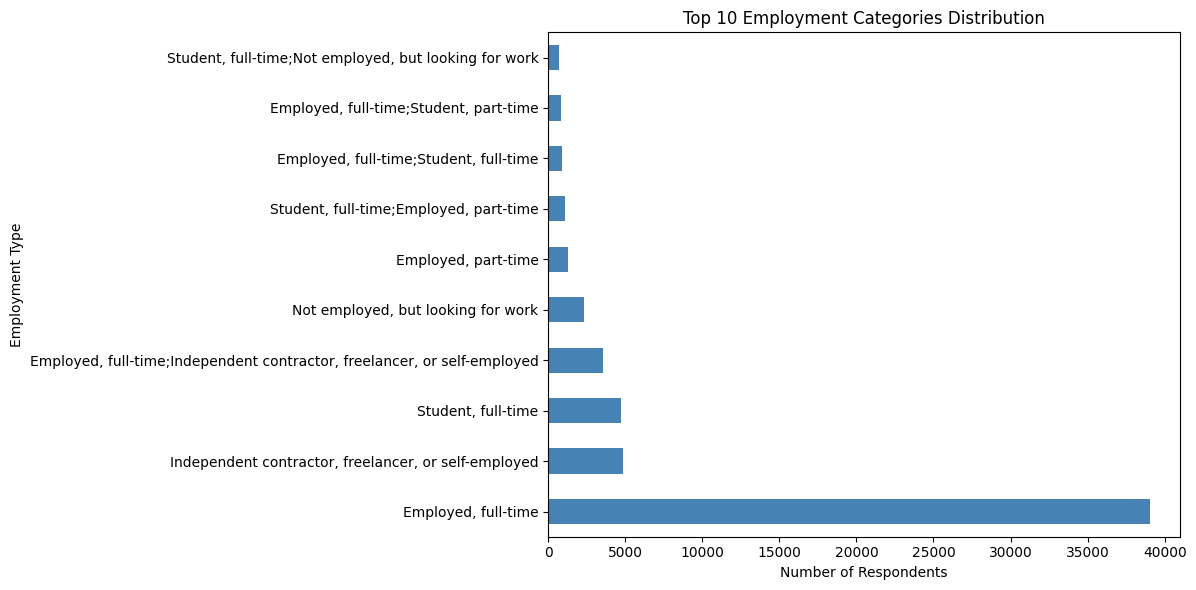

Employment distribution visualization saved!


In [9]:
# Visualize top 10 Employment categories after imputation
top_employment = df['Employment'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_employment.plot(kind='barh', color='steelblue')
plt.title('Top 10 Employment Categories Distribution')
plt.xlabel('Number of Respondents')
plt.ylabel('Employment Type')
plt.tight_layout()
plt.savefig('employment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Employment distribution visualization saved!")